## Concepts of vLLM

#### Infrastructure used to demonstrate

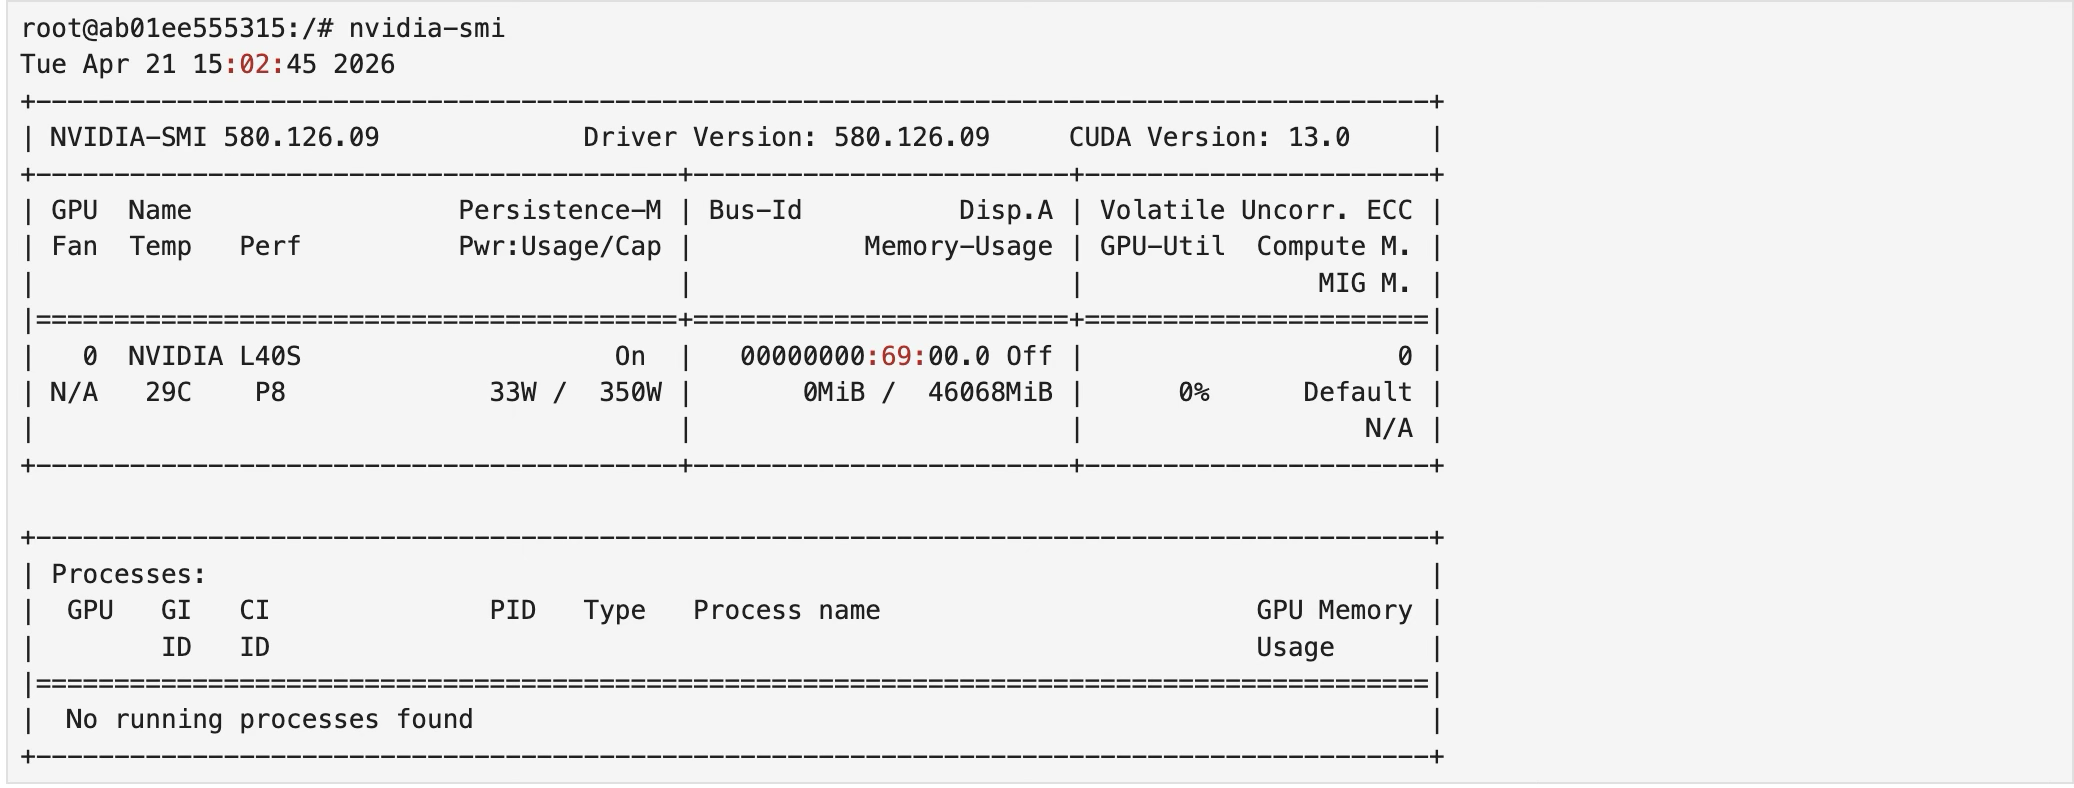

In [1]:
!pip install vllm
!pip install --upgrade typing_extensions pydantic pydantic-core


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip


#### Simple inferencing

In [2]:
from vllm import LLM, SamplingParams

In [3]:
prompts = [
    "Hello, my name is",
    "The president of the United States is",
    "The capital of France is",
    "The future of AI is",
]
sampling_params = SamplingParams(temperature=0.8, top_p=0.95)

In [6]:
def main():
    llm = LLM(model="TinyLlama/TinyLlama-1.1B-Chat-v1.0")
    outputs = llm.generate(prompts, sampling_params)
    return outputs

if __name__ == "__main__":
    _outputs = main()
    print(_outputs)

INFO 04-21 15:13:45 [utils.py:233] non-default args: {'disable_log_stats': True, 'model': 'TinyLlama/TinyLlama-1.1B-Chat-v1.0'}
INFO 04-21 15:13:46 [model.py:549] Resolved architecture: LlamaForCausalLM
INFO 04-21 15:13:46 [model.py:1678] Using max model len 2048
(EngineCore pid=2277) INFO 04-21 15:13:46 [core.py:105] Initializing a V1 LLM engine (v0.19.1) with config: model='TinyLlama/TinyLlama-1.1B-Chat-v1.0', speculative_config=None, tokenizer='TinyLlama/TinyLlama-1.1B-Chat-v1.0', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, tokenizer_revision=None, trust_remote_code=False, dtype=torch.bfloat16, max_seq_len=2048, download_dir=None, load_format=auto, tensor_parallel_size=1, pipeline_parallel_size=1, data_parallel_size=1, decode_context_parallel_size=1, dcp_comm_backend=ag_rs, disable_custom_all_reduce=False, quantization=None, enforce_eager=False, enable_return_routed_experts=False, kv_cache_dtype=auto, device_config=cuda, structured_outputs_config=StructuredOutputs

(EngineCore pid=2277) <frozen importlib._bootstrap_external>:1241: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
(EngineCore pid=2277) <frozen importlib._bootstrap_external>:1241: FutureWarning: The cuda.nvrtc module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.nvrtc module instead.


(EngineCore pid=2277) INFO 04-21 15:13:48 [weight_utils.py:625] No model.safetensors.index.json found in remote.


Loading safetensors checkpoint shards:   0% Completed | 0/1 [00:00<?, ?it/s]


(EngineCore pid=2277) INFO 04-21 15:13:48 [default_loader.py:384] Loading weights took 0.25 seconds
(EngineCore pid=2277) INFO 04-21 15:13:49 [gpu_model_runner.py:4820] Model loading took 2.05 GiB memory and 1.302754 seconds
(EngineCore pid=2277) INFO 04-21 15:13:50 [backends.py:1051] Using cache directory: /root/.cache/vllm/torch_compile_cache/1d8d519854/rank_0_0/backbone for vLLM's torch.compile
(EngineCore pid=2277) INFO 04-21 15:13:50 [backends.py:1111] Dynamo bytecode transform time: 1.07 s
(EngineCore pid=2277) INFO 04-21 15:13:51 [backends.py:285] Directly load the compiled graph(s) for compile range (1, 8192) from the cache, took 0.884 s
(EngineCore pid=2277) INFO 04-21 15:13:51 [decorators.py:305] Directly load AOT compilation from path /root/.cache/vllm/torch_compile_cache/torch_aot_compile/09d4cb6026cb77b59f42e0535b783468017d63c4aa0b8e77fc28ded216c217c0/rank_0_0/model
(EngineCore pid=2277) INFO 04-21 15:13:51 [monitor.py:48] torch.compile took 2.07 s in total
(EngineCore pid

Capturing CUDA graphs (mixed prefill-decode, PIECEWISE): 100%|██████████| 51/51 [00:00<00:00, 67.89it/s]
Capturing CUDA graphs (decode, FULL): 100%|██████████| 35/35 [00:00<00:00, 81.85it/s]


(EngineCore pid=2277) INFO 04-21 15:13:59 [gpu_model_runner.py:6046] Graph capturing finished in 2 secs, took 0.35 GiB
(EngineCore pid=2277) INFO 04-21 15:13:59 [gpu_worker.py:597] CUDA graph pool memory: 0.35 GiB (actual), 0.29 GiB (estimated), difference: 0.05 GiB (15.6%).
(EngineCore pid=2277) INFO 04-21 15:13:59 [core.py:283] init engine (profile, create kv cache, warmup model) took 10.11 seconds


Rendering prompts:   0%|          | 0/4 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/4 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

(EngineCore pid=2277) INFO 04-21 15:14:00 [core.py:1210] Shutdown initiated (timeout=0)
(EngineCore pid=2277) INFO 04-21 15:14:00 [core.py:1233] Shutdown complete
[RequestOutput(request_id=0, prompt='Hello, my name is', prompt_token_ids=[1, 15043, 29892, 590, 1024, 338], encoder_prompt=None, encoder_prompt_token_ids=None, prompt_logprobs=None, outputs=[CompletionOutput(index=0, text='\n20. How did the group meet and begin their journey together?\n', token_ids=[13, 29906, 29900, 29889, 1128, 1258, 278, 2318, 5870, 322, 3380, 1009, 16342, 4208, 29973, 13], routed_experts=None, cumulative_logprob=None, logprobs=None, finish_reason=length, stop_reason=None)], finished=True, metrics=None, lora_request=None, num_cached_tokens=0), RequestOutput(request_id=1, prompt='The president of the United States is', prompt_token_ids=[1, 450, 6673, 310, 278, 3303, 3900, 338], encoder_prompt=None, encoder_prompt_token_ids=None, prompt_logprobs=None, outputs=[CompletionOutput(index=0, text=' required by la